# Mag 7 ATM LEAP Strategy Backtest

This notebook backtests an ATM LEAP strategy that splits capital evenly across all Magnificent 7 stocks.

## Strategy
- **Tickers**: AAPL, MSFT, GOOGL, AMZN, META, NVDA, TSLA
- **Strike**: At-the-money (strike factor = 1.0)
- **Duration**: 1-year LEAPs (365 days)
- **Roll**: When position gets within 90 days of expiration
- **Allocation**: Equal weight across all 7 names
- **Period**: 10 years (2016–2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "../..")

from utils.simulation import BacktestSimulation
from strategies.mag7_leap_strategy import create_mag7_leap_strategy, MAG7_TICKERS
from datetime import datetime

In [6]:
# Configuration
tickers = MAG7_TICKERS
start = datetime(2016, 1, 1)
end = datetime(2026, 1, 1)
initial_cash = 10000

# Create the strategy
strategy = create_mag7_leap_strategy(
    tickers=tickers,
    strike_factor=1.0,   # ATM
    days=365,            # 1-year LEAPs
    interest_rate=0.05,
    roll_threshold=90,   # Roll at 3 months to expiration
)

# Run backtest
sim = BacktestSimulation(
    tickers=tickers,
    start_date=start,
    end_date=end,
    initial_cash=initial_cash,
    strategy_callback=strategy,
)

results_df = sim.run()

Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


/Users/ryan/git/quantitative-trading-models/strategies/leap/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
/Users/ryan/git/quantitative-trading-models/strategies/leap/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
/Users/ryan/git/quantitative-trading-models/strategies/leap/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
/Users/ryan/git/quantitative-trading-models/strategies/leap/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, prog


=== Performance Summary ===
Initial Value: $10,000.00
Final Value: $2,711,652.46
Total Return: 27016.52%
Sharpe Ratio: 1.18
Max Drawdown: 75.91%
Annualized Volatility: 66.74%


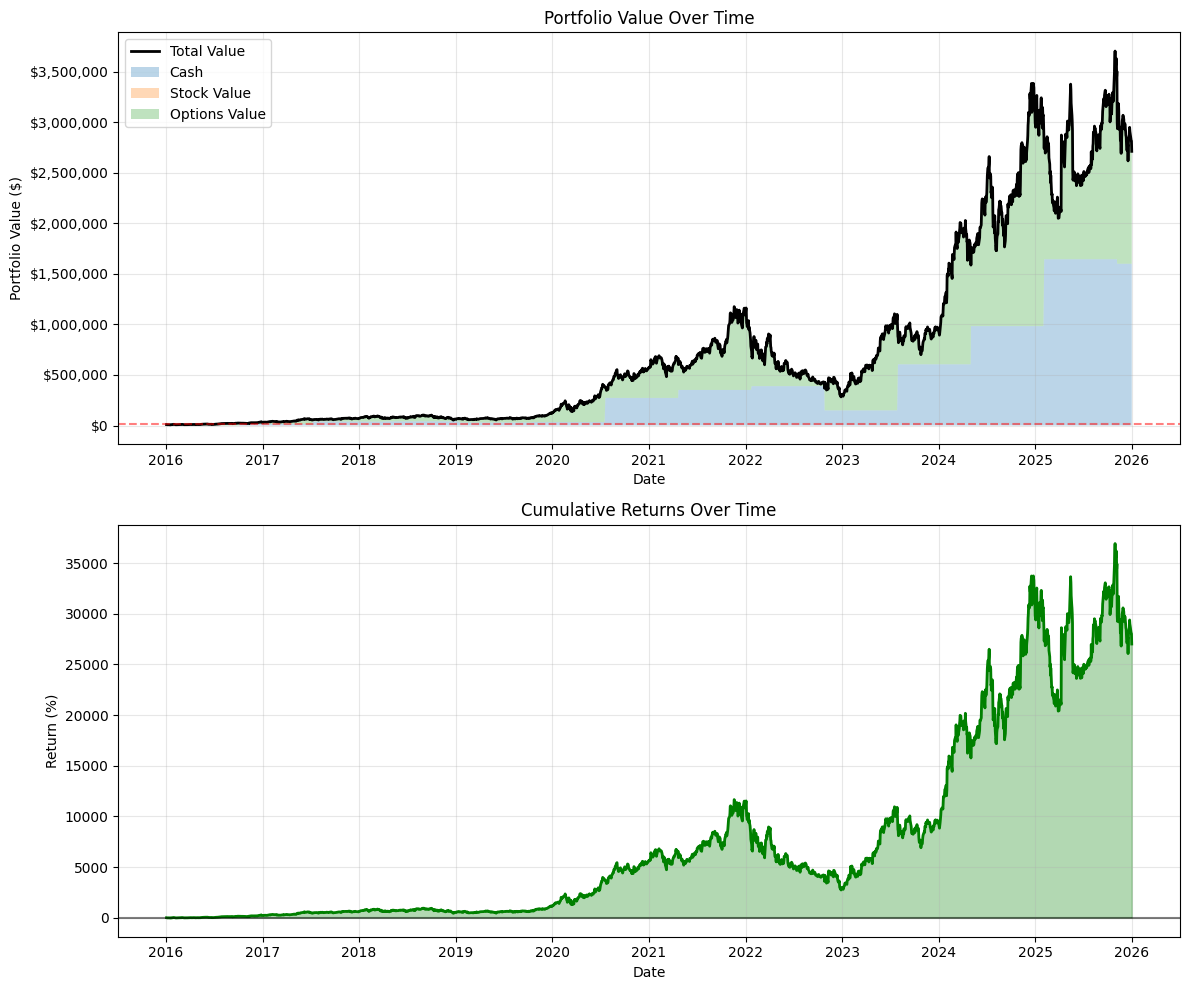

In [7]:
# Performance summary
sim.print_performance_stats()
sim.plot_portfolio_history()

In [8]:
# Transaction log
tx = sim.get_transactions()
if not tx.empty:
    print(f"Total transactions: {len(tx)}")
    print(f"\nTransaction breakdown:")
    print(tx['action'].value_counts())
    print(f"\nTransactions by ticker:")
    print(tx['ticker'].value_counts())
    print(f"\nFirst 20 transactions:")
    display(tx.head(20))

Total transactions: 189

Transaction breakdown:
action
BUY_CALL      98
CLOSE_CALL    91
Name: count, dtype: int64

Transactions by ticker:
ticker
AAPL     27
MSFT     27
GOOGL    27
AMZN     27
META     27
NVDA     27
TSLA     27
Name: count, dtype: int64

First 20 transactions:


,date,action,ticker,contracts,strike,premium_per_share,total_premium,expiration
0,2016-01-04,BUY_CALL,AAPL,5,23.730949,2.670525,1335.262403,2017-01-03
1,2016-01-04,BUY_CALL,MSFT,2,47.874195,5.119765,1023.952923,2017-01-03
2,2016-01-04,BUY_CALL,GOOGL,3,37.660736,4.090098,1227.029446,2017-01-03
3,2016-01-04,BUY_CALL,AMZN,3,31.849501,4.415675,1324.702484,2017-01-03
4,2016-01-04,BUY_CALL,META,1,101.424080,11.801109,1180.110877,2017-01-03
5,2016-01-04,BUY_CALL,NVDA,150,0.789545,0.095148,1427.218073,2017-01-03
6,2016-01-04,BUY_CALL,TSLA,5,14.894000,2.633531,1316.765614,2017-01-03
7,2016-10-06,CLOSE_CALL,AAPL,5,23.730949,2.890870,1445.434944,2017-01-03
8,2016-10-06,BUY_CALL,AAPL,1,26.091492,2.964386,296.438554,2017-10-06
9,2016-10-06,CLOSE_CALL,MSFT,2,47.874195,4.351853,870.370545,2017-01-03


/var/folders/n0/v71fgjdd4d1d0dgsdk6fjqbw0000gn/T/ipykernel_57729/519328621.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)
/var/folders/n0/v71fgjdd4d1d0dgsdk6fjqbw0000gn/T/ipykernel_57729/519328621.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)
/var/folders/n0/v71fgjdd4d1d0dgsdk6fjqbw0000gn/T/ipykernel_57729/519328621.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)
/var/folders/n0/v71fgjdd4d1d0dgsdk6fjqbw0000gn/T/ipykernel_57729/519328621.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)
/var/folders/n0/v71fgjdd4d1d0dgsdk6fjqbw0000gn/T/ipykernel_57729/519328621.py:7: FutureWarning: YF.downl

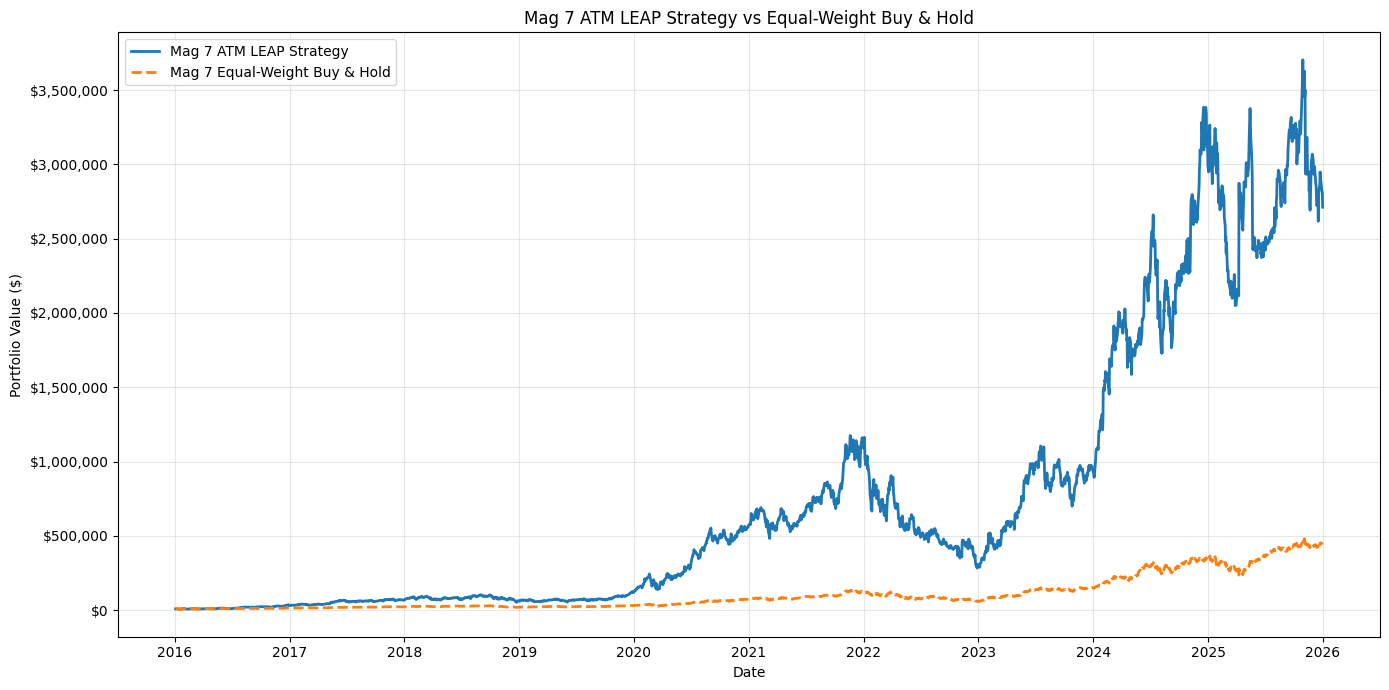


LEAP Strategy Final Value:     $2,711,652.46  (+27016.5%)
Buy & Hold Final Value:        $  442,818.68  (+4328.2%)


In [9]:
# Compare against buy-and-hold of the Mag 7 (equal weight)
import yfinance as yf

# Download price data for comparison
benchmark_data = {}
for ticker in tickers:
    df = yf.download(ticker, start=start, end=end, progress=False)
    benchmark_data[ticker] = df['Close']

# Calculate equal-weight buy-and-hold returns
benchmark_returns = pd.DataFrame()
for ticker in tickers:
    prices = benchmark_data[ticker]
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]
    benchmark_returns[ticker] = prices / prices.iloc[0]

benchmark_returns['equal_weight'] = benchmark_returns.mean(axis=1)
benchmark_returns['equal_weight_value'] = benchmark_returns['equal_weight'] * initial_cash

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 7))

leap_df = pd.DataFrame(sim.history)
ax.plot(leap_df['date'], leap_df['total_value'], label='Mag 7 ATM LEAP Strategy', linewidth=2)
ax.plot(benchmark_returns.index, benchmark_returns['equal_weight_value'],
        label='Mag 7 Equal-Weight Buy & Hold', linewidth=2, linestyle='--')

ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title('Mag 7 ATM LEAP Strategy vs Equal-Weight Buy & Hold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Print benchmark stats
bh_final = benchmark_returns['equal_weight_value'].iloc[-1]
bh_return = (bh_final / initial_cash - 1) * 100
leap_final = leap_df['total_value'].iloc[-1]
leap_return = (leap_final / initial_cash - 1) * 100

print(f"\n{'='*50}")
print(f"LEAP Strategy Final Value:     ${leap_final:>12,.2f}  ({leap_return:>+.1f}%)")
print(f"Buy & Hold Final Value:        ${bh_final:>12,.2f}  ({bh_return:>+.1f}%)")
print(f"{'='*50}")